In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [9]:
# STEP 1: LOAD DATA & CLEAN IRRELEVANT COLUMNS
# =====================================================================
# Load your local downloaded Kaggle file from your folder
churn = pd.read_csv('Churn_Modelling.csv')
print("Dataset Successfully Loaded!")
print(f"Total Rows: {churn.shape[0]} | Total Columns: {churn.shape[1]}")
print("\n--- Initial Columns ---")
print(churn.columns.tolist())

# Drop identification columns that have zero predictive power
churn = churn.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

# Check for any missing values to ensure data cleanliness
print("\n--- Missing Values Matrix ---")
print(churn.isnull().sum())

Dataset Successfully Loaded!
Total Rows: 10000 | Total Columns: 14

--- Initial Columns ---
['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

--- Missing Values Matrix ---
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [10]:
# STEP 2: CATEGORICAL ENCODING (Text to Numbers)
# One-Hot Encode 'Geography' and 'Gender' columns into binary categories
categorical_cols = ['Geography', 'Gender']
churn = pd.get_dummies(churn, columns=categorical_cols, drop_first=True)

# Separate features (X) and our target variable 'Exited' (y)
# Exited: 1 = Customer Churned (Left), 0 = Customer Retained (Stayed)
X = churn.drop(columns=['Exited'])
y = churn['Exited']

# Split data into 80% Training and 20% Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
# STEP 3: MODEL TRAINING (Decision Tree Classifier)
# We set max_depth=5 to stop the tree from growing endlessly and overfitting
model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

Model Accuracy Score
Decision Tree Baseline Accuracy: 85.75%


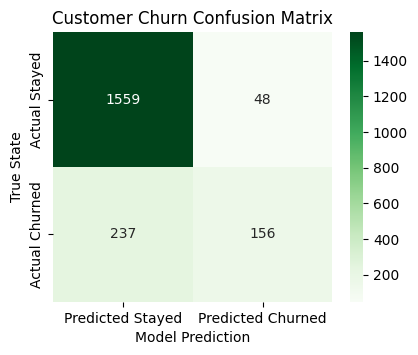

In [12]:
# STEP 4: MODEL EVALUATION
y_pred = model.predict(X_test)

print("Model Accuracy Score")
print(f"Decision Tree Baseline Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

# Generate a clean Confusion Matrix chart
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4.5, 3.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted Stayed', 'Predicted Churned'],
            yticklabels=['Actual Stayed', 'Actual Churned'])
plt.title('Customer Churn Confusion Matrix')
plt.ylabel('True State')
plt.xlabel('Model Prediction')
plt.show()

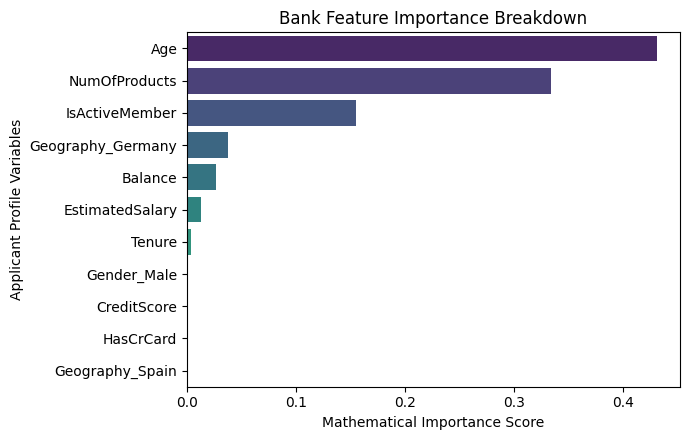

In [14]:
# STEP 5: FEATURE IMPORTANCE ANALYSIS
# Extract mathematical weights from our trained tree model
importances = model.feature_importances_

# Map the scores back to their matching column labels
feature_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Render a beautiful horizontal chart ranking the features
plt.figure(figsize=(7, 4.5))
sns.barplot(data=feature_imp, x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title('Bank Feature Importance Breakdown')
plt.xlabel('Mathematical Importance Score')
plt.ylabel('Applicant Profile Variables')
plt.tight_layout()
plt.show()

In [19]:
# Step 6: TESTING THE MODEL ON THE REMAINING 20% DATA
search_customer_id = 15777060

# 1. Look up the customer in the original dataset to find their name and profile
original_df = pd.read_csv('Churn_Modelling.csv')
customer_record = original_df[original_df['CustomerId'] == search_customer_id]

if customer_record.empty:
    print(f"❌ Error: Customer ID {search_customer_id} not found in the database.")
else:
    # Extract the customer's name for a personalized display
    customer_name = customer_record['Surname'].values[0]
    
    # 2. Extract just the mathematical features for this customer
    # We grab the same index from our processed X matrix to ensure encoding matches perfectly
    idx = customer_record.index[0]
    customer_features = X.loc[[idx]]
    
    # 3. Let the model calculate the prediction and probability
    prediction = model.predict(customer_features)
    probability = model.predict_proba(customer_features)[0][1] # Probability of leaving
    
    # 4. Display the dynamic personalized results
    print(f"🔍 AI ANALYSIS FOR CUSTOMER: {customer_name} (ID: {search_customer_id})")
    print(f"Risk Assessment: {probability * 100:.2f}% chance of leaving the bank.")
    
    if prediction[0] == 1:
        print(f"🚨 STATUS: HIGH FLIGHT RISK")
        print(f"👉 Action: Alert the account manager to contact {customer_name} with a retention offer.")
    else:
        print(f"✅ STATUS: LOAYL CUSTOMER (STABLE)")

🔍 AI ANALYSIS FOR CUSTOMER: Olszewski (ID: 15777060)
Risk Assessment: 10.95% chance of leaving the bank.
✅ STATUS: LOAYL CUSTOMER (STABLE)
